### Autores 
Robinson Marin Moralez 

Guillermo Leon Loaiza Mesa

### Crecion del Catalogo, Shchema y Tablas

In [0]:
%sql
--Crear el Catálogo (Contenedor principal)
CREATE CATALOG IF NOT EXISTS proyectos_bigdata; 

--Crear el Esquema (Base de Datos)
CREATE SCHEMA IF NOT EXISTS proyectos_bigdata.powerlifting_romen; 

--Usar el Esquema
USE proyectos_bigdata.powerlifting_romen;

In [0]:
%sql
--DDL para la tabla de Encuentros (meets.csv)
CREATE TABLE IF NOT EXISTS proyectos_bigdata.powerlifting_romen.tbl_encuentro (
    MeetID LONG NOT NULL COMMENT "Llave primaria",
    MeetPath STRING,
    Federation STRING,
    Date STRING,
    MeetCountry STRING,
    MeetState STRING,
    MeetTown  STRING,
    MeetName STRING,
    PRIMARY KEY (MeetID)
);

transformación de fecha

In [0]:
%sql
SELECT 
    MeetID, 
    Federation, 
    Date AS Fecha_Original_String, 
    to_date(Date) AS Fecha_Convertida
FROM proyectos_bigdata.powerlifting_romen.tbl_encuentro
LIMIT 20;

MeetID,Federation,Fecha_Original_String,Fecha_Convertida
0,365Strong,2016-10-29,2016-10-29
1,365Strong,2016-11-19,2016-11-19
2,365Strong,2016-07-09,2016-07-09
3,365Strong,2016-06-11,2016-06-11
4,365Strong,2016-04-10,2016-04-10
5,365Strong,2017-04-22,2017-04-22
6,365Strong,2017-01-21,2017-01-21
7,365Strong,2017-06-10,2017-06-10
8,365Strong,2017-07-15,2017-07-15
9,365Strong,2017-08-12,2017-08-12


In [0]:
%sql
-- Validación si hay fechas que fallaron en la conversión (quedarían NULL)
SELECT *
FROM proyectos_bigdata.powerlifting_romen.tbl_encuentro
WHERE Date IS NOT NULL 
  AND to_date(Date) IS NULL;

MeetID,MeetPath,Federation,Date,MeetCountry,MeetState,MeetTown,MeetName


Columnas apartir de la fecha

In [0]:
%sql
SELECT *, to_date(Date) AS Fecha_Real
FROM proyectos_bigdata.powerlifting_romen.tbl_encuentro;
SELECT 
    MeetID,
    Federation,
    to_date(Date) AS Fecha_Real, 
    year(to_date(Date)) AS Anio, --columna para el año
    month(to_date(Date)) AS Mes, --columna para el mes
    day(to_date(Date)) AS Dia, --columna para el día
    --Usamos weekday() que da 0=Lunes...6=Domingo. Sumamos 1 para obtener 1-7.
    weekday(to_date(Date)) + 1 AS Dia_Semana_Num, 
    -- Usamos CASE para traducir el número del día al nombre en Español
    CASE weekday(to_date(Date))
        WHEN 0 THEN 'Lunes'
        WHEN 1 THEN 'Martes'
        WHEN 2 THEN 'Miércoles'
        WHEN 3 THEN 'Jueves'
        WHEN 4 THEN 'Viernes'
        WHEN 5 THEN 'Sábado'
        WHEN 6 THEN 'Domingo'
    END AS Nombre_Dia
FROM proyectos_bigdata.powerlifting_romen.tbl_encuentro
LIMIT 20;

MeetID,Federation,Fecha_Real,Anio,Mes,Dia,Dia_Semana_Num,Nombre_Dia
0,365Strong,2016-10-29,2016,10,29,6,Sábado
1,365Strong,2016-11-19,2016,11,19,6,Sábado
2,365Strong,2016-07-09,2016,7,9,6,Sábado
3,365Strong,2016-06-11,2016,6,11,6,Sábado
4,365Strong,2016-04-10,2016,4,10,7,Domingo
5,365Strong,2017-04-22,2017,4,22,6,Sábado
6,365Strong,2017-01-21,2017,1,21,6,Sábado
7,365Strong,2017-06-10,2017,6,10,6,Sábado
8,365Strong,2017-07-15,2017,7,15,6,Sábado
9,365Strong,2017-08-12,2017,8,12,6,Sábado


estas nuevas columnas permiten identificar el crecimiento historico del deporte, el Mes revela la estacionalidad "temporadas altas de competencia", y el Día junto al Nombre del Dia, son claves para entender la logística de los eventos "preferencia por fines de semana" y asi poder verificar la calidad de los datos.

Resumen mensual

In [0]:
%sql
CREATE OR REPLACE TABLE proyectos_bigdata.powerlifting_romen.resumen_mensual AS
SELECT 
    year(to_date(Date)) AS Anio,
    month(to_date(Date)) AS Mes,
    -- Conteo total de eventos en ese mes
    COUNT(*) AS Total_Eventos,
    -- Conteo de cuántas federaciones distintas tuvieron eventos
    COUNT(DISTINCT Federation) AS Federaciones_Activas
FROM proyectos_bigdata.powerlifting_romen.tbl_encuentro
WHERE Date IS NOT NULL
GROUP BY year(to_date(Date)), month(to_date(Date))
ORDER BY Anio DESC, Mes DESC;

-- EVIDENCIA: Mostrar los primeros 10 registros de la nueva tabla resumen
SELECT * FROM proyectos_bigdata.powerlifting_romen.resumen_mensual LIMIT 10;

Anio,Mes,Total_Eventos,Federaciones_Activas
2018,1,46,10
2017,12,111,21
2017,11,95,20
2017,10,103,25
2017,9,129,26
2017,8,99,20
2017,7,89,25
2017,6,122,23
2017,5,97,23
2017,4,137,27


Limpieza, antes y después

Muestra cómo estaban las columnas antes y después de limpiar.

Funciones aplicadas: lower "minúsculas", trim "recortar espacios", coalesce "nulos".

In [0]:
%sql
SELECT 
    --LIMPIEZA DE TEXTO (Normalización)
    Federation AS Federation_Original,
    lower(trim(Federation)) AS Federation_Limpia, -- Convierte a minúsculas y quita espacios
    
      --MANEJO DE NULOS (Imputación)
    MeetCountry AS Country_Original,
    coalesce(MeetCountry, 'DESCONOCIDO') AS Country_Imputado, 

    --CASTEO DE TIPOS (Validación de Fechas)
    Date AS Fecha_String,
    to_date(Date) AS Fecha_Casteada,

    -- ENRIQUECIMIENTO (Mapeo de Estados)
    MeetState AS Estado_Original,
    CASE 
        WHEN MeetState IS NULL OR trim(MeetState) = '' THEN 'DESCONOCIDO'
        WHEN MeetState = 'CA' THEN 'California'
        
        WHEN MeetState = 'TX' THEN 'Texas'
        WHEN MeetState = 'FL' THEN 'Florida'
        WHEN MeetState = 'NC' THEN 'North Carolina'
        WHEN MeetState = 'NY' THEN 'New York'
        WHEN MeetState = 'OH' THEN 'Ohio'
        WHEN MeetState = 'GA' THEN 'Georgia'
        WHEN MeetState = 'VA' THEN 'Virginia'
        WHEN MeetState = 'MO' THEN 'Misuri'
        WHEN MeetState = 'SC' THEN 'Carolina del Sur'
        WHEN MeetState = 'IN' THEN 'Indiana'
        WHEN MeetState = 'NV' THEN 'Nevada'
        WHEN MeetState = 'OR' THEN 'Oregon'
        WHEN MeetState = 'AK' THEN 'Alaska'
        WHEN MeetState = 'KS' THEN 'Kansas'
        WHEN MeetState = 'AZ' THEN 'Arizona'
        WHEN MeetState = 'NE' THEN 'Nebraska'
        WHEN MeetState = 'IA' THEN 'Iowa'
        WHEN MeetState = 'PA' THEN 'Pennsylvania'
        WHEN MeetState = 'CO' THEN 'Colorado'
        WHEN MeetState = 'NM' THEN 'Nueva México'
        WHEN MeetState = 'UT' THEN 'Utah'
        WHEN MeetState = 'ID' THEN 'Idaho'
        WHEN MeetState = 'MI' THEN 'Michigan'
        WHEN MeetState = 'WV' THEN 'Virginia Occidental'
        WHEN MeetState = 'KY' THEN 'Kentucky'
        WHEN MeetState = 'AL' THEN 'Alabama'
        WHEN MeetState = 'MS' THEN 'Mississippi'
        WHEN MeetState = 'WY' THEN 'Wyoming'

  -- Si no está en la lista anterior, mantenemos el valor original
        ELSE MeetState 
    END AS Estado_Nombre_Completo

FROM proyectos_bigdata.powerlifting_romen.tbl_encuentro
WHERE year(to_date(Date)) BETWEEN 1950 AND 2025
LIMIT 30;

Federation_Original,Federation_Limpia,Country_Original,Country_Imputado,Fecha_String,Fecha_Casteada,Estado_Original,Estado_Nombre_Completo
365Strong,365strong,USA,USA,2016-10-29,2016-10-29,NC,North Carolina
365Strong,365strong,USA,USA,2016-11-19,2016-11-19,MO,Misuri
365Strong,365strong,USA,USA,2016-07-09,2016-07-09,NC,North Carolina
365Strong,365strong,USA,USA,2016-06-11,2016-06-11,SC,Carolina del Sur
365Strong,365strong,USA,USA,2016-04-10,2016-04-10,SC,Carolina del Sur
365Strong,365strong,USA,USA,2017-04-22,2017-04-22,NC,North Carolina
365Strong,365strong,USA,USA,2017-01-21,2017-01-21,GA,Georgia
365Strong,365strong,USA,USA,2017-06-10,2017-06-10,MO,Misuri
365Strong,365strong,USA,USA,2017-07-15,2017-07-15,SC,Carolina del Sur
365Strong,365strong,USA,USA,2017-08-12,2017-08-12,NC,North Carolina


al Normalizar los textos con "lower, trim", castear fechas"to date" nos facilita el analisis y para realizar agrupaciones temporal sin duplicados. Imputar nulos "coalesce" cuantifica la falta de datos, con"case" estandarizamos los estados para que sea mas facil su geolocalizacion

Visualizaciones con librerías

In [0]:
%sql
--GRAFICA 1: Top 10 Federaciones (Gráfico de Barras)
-- Ejes: X = Federation, Y = Total_Eventos
SELECT 
    Federation, 
    COUNT(*) as Total_Eventos 
FROM proyectos_bigdata.powerlifting_romen.tbl_encuentro 
GROUP BY Federation 
ORDER BY Total_Eventos DESC 
LIMIT 10;
--en el + podemos dar en visualizacion y muestra la grafica 
/* INTERPRETACIÓN GRÁFICA 1:
   Se evidencia una alta concentración de eventos en pocas federaciones dominantes, 
   lo que sugiere un mercado monopolizado. Las federaciones menores ("long tail") 
   tienen presencia marginal, indicando barreras de entrada altas o nichos específicos.
*/

Federation,Total_Eventos
NSF,2517
USAPL,976
CPU,969
USPA,864
THSPA,670
PA,493
SPF,480
RPS,334
NZPF,179
NASA,103


In [0]:
%sql
-- GRAFICA 2: Eventos por Día de la Semana (Gráfico de Barras/Pastel)
-- Ejes: X = Nombre_Dia, Y = Total_Eventos
SELECT 
    CASE weekday(to_date(Date))
        WHEN 0 THEN '1-Lunes'
        WHEN 1 THEN '2-Martes'
        WHEN 2 THEN '3-Miércoles'
        WHEN 3 THEN '4-Jueves'
        WHEN 4 THEN '5-Viernes'
        WHEN 5 THEN '6-Sábado'
        WHEN 6 THEN '7-Domingo'
    END AS Nombre_Dia,
    COUNT(*) as Total_Eventos
FROM proyectos_bigdata.powerlifting_romen.tbl_encuentro
WHERE Date IS NOT NULL
GROUP BY weekday(to_date(Date))
ORDER BY weekday(to_date(Date));
-- en el + podemos dar click en visualizacion y muestra la grafica 
/* INTERPRETACIÓN GRÁFICA 2:
   La actividad competitiva alcanza su pico máximo durante el fin de semana (Sábado y Domingo),
   validando la naturaleza amateur del deporte. La presencia residual en días laborales 
   podría señalar errores de registro o competiciones profesionales de larga duración.
*/

Nombre_Dia,Total_Eventos
1-Lunes,246
2-Martes,198
3-Miércoles,338
4-Jueves,403
5-Viernes,574
6-Sábado,5789
7-Domingo,934


mismas graficas en python con librerias

Generando Gráfica 1: Top 10 Federaciones...


/home/spark-364da6ec-7e43-40f8-bec4-60/.ipykernel/4265/command-8607631304309438-3845472364:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf_federations, x="Total_Eventos", y="Federation", palette="viridis")


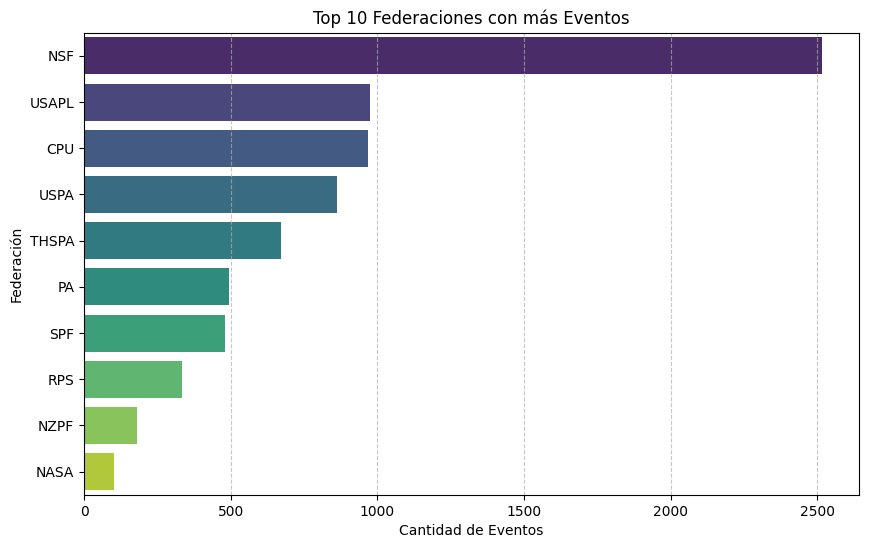

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, count, to_date, date_format, dayofweek

# 1. CARGA DE DATOS
# Conectamos a tu tabla existente
table_name = "proyectos_bigdata.powerlifting_romen.tbl_encuentro"
df = spark.table(table_name)

# ==========================================
# GRÁFICA 1: Top 10 Federaciones
# ==========================================
print("Generando Gráfica 1: Top 10 Federaciones...")

# A) Preparación de datos en Spark (Agregación)
# Agrupamos por Federación, contamos y nos quedamos con los 10 primeros
df_top_federations = df.groupBy("Federation") \
    .agg(count("*").alias("Total_Eventos")) \
    .orderBy(col("Total_Eventos").desc()) \
    .limit(10)

# B) Convertir a Pandas (Solo traemos 10 filas a la memoria del driver)
pdf_federations = df_top_federations.toPandas()

# C) Graficar con Seaborn/Matplotlib
plt.figure(figsize=(10, 6))
sns.barplot(data=pdf_federations, x="Total_Eventos", y="Federation", palette="viridis")

plt.title("Top 10 Federaciones con más Eventos")
plt.xlabel("Cantidad de Eventos")
plt.ylabel("Federación")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show() # Muestra el gráfico en la celda del notebook



Generando Gráfica 2: Eventos por Día de la Semana...


/home/spark-364da6ec-7e43-40f8-bec4-60/.ipykernel/4265/command-8607631304309442-3474082509:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pdf_dias, x="Nombre_Dia", y="Total_Eventos", order=dias_ordenados, palette="magma")


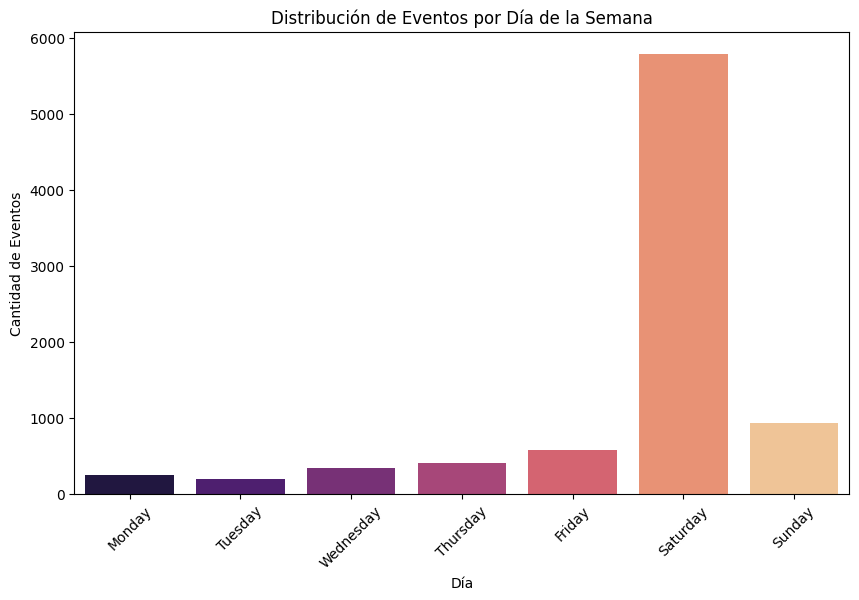

In [0]:
# ==========================================
# GRÁFICA 2: Distribución por Día de la Semana
# ==========================================
print("Generando Gráfica 2: Eventos por Día de la Semana...")

# A) Preparación de datos en Spark
# Convertimos fecha, extraemos el nombre del día y el número para ordenar correctamente (Lunes=1...)
# Nota: dayofweek en Spark por defecto considera Domingo=1. Ajustaremos para ordenar Lunes-Domingo visualmente.
df_dias = df.withColumn("Fecha_Real", to_date(col("Date"))) \
    .withColumn("Nombre_Dia", date_format(col("Fecha_Real"), "EEEE")) \
    .withColumn("Num_Dia", dayofweek(col("Fecha_Real"))) \
    .filter(col("Fecha_Real").isNotNull()) \
    .groupBy("Nombre_Dia", "Num_Dia") \
    .agg(count("*").alias("Total_Eventos")) \
    .orderBy("Num_Dia") # Ordenamos cronológicamente

# B) Convertir a Pandas
pdf_dias = df_dias.toPandas()

# Ajuste manual para asegurar orden Lunes -> Domingo si el locale es inglés o variado
# (Opcional: reordenar el dataframe de pandas si es necesario, pero el orderBy de Spark suele bastar)
dias_ordenados = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
# Si tus datos salen en español, cambia la lista anterior a ["Lunes", "Martes"...]

plt.figure(figsize=(10, 6))
sns.barplot(data=pdf_dias, x="Nombre_Dia", y="Total_Eventos", order=dias_ordenados, palette="magma")

plt.title("Distribución de Eventos por Día de la Semana")
plt.xlabel("Día")
plt.ylabel("Cantidad de Eventos")
plt.xticks(rotation=45)
plt.show()

Lenguaje de trabajo  SQL y Spark

In [0]:
# EQUIVALENCIA DE TRANSFORMACIÓN (Limpieza y Fechas)
from pyspark.sql.functions import col, to_date, lower, trim, year, month, count, when
# Cargamos la tabla que estamos usando en SQL
table_name = "proyectos_bigdata.powerlifting_romen.tbl_encuentro"
df = spark.table(table_name)
print("Equivalencia: Transformación (Limpieza)")

df_transformado = df \
    .withColumn("Federation_Limpia", lower(trim(col("Federation")))) \
    .withColumn("Fecha_Real", to_date(col("Date"))) \
    .withColumn("Estado_Imputado", when(col("MeetState").isNull(), "DESCONOCIDO").otherwise(col("MeetState")))
# Mostramos el resultado (equivalente al SELECT LIMIT 5)
display(df_transformado.select("Federation", "Federation_Limpia", "Date", "Fecha_Real", "Estado_Imputado").limit(5))

# EQUIVALENCIA DE AGREGACIÓN (Conteo Mensual)
print("\n Equivalencia: Agregación (Resumen Mensual)")

df_resumen = df_transformado \
    .withColumn("Anio", year(col("Fecha_Real"))) \
    .withColumn("Mes", month(col("Fecha_Real"))) \
    .groupBy("Anio", "Mes") \
    .agg(count("*").alias("Total_Eventos")) \
    .orderBy(col("Anio").desc(), col("Mes").desc())

# Mostramos el resultado
display(df_resumen.limit(10))

Equivalencia: Transformación (Limpieza)


Federation,Federation_Limpia,Date,Fecha_Real,Estado_Imputado
365Strong,365strong,2016-10-29,2016-10-29,NC
365Strong,365strong,2016-11-19,2016-11-19,MO
365Strong,365strong,2016-07-09,2016-07-09,NC
365Strong,365strong,2016-06-11,2016-06-11,SC
365Strong,365strong,2016-04-10,2016-04-10,SC



 Equivalencia: Agregación (Resumen Mensual)


Anio,Mes,Total_Eventos
2018,1,46
2017,12,111
2017,11,95
2017,10,103
2017,9,129
2017,8,99
2017,7,89
2017,6,122
2017,5,97
2017,4,137
